In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Rental_Property_Dataset.csv')


df.head()

,rentfaster_id,city,province,address,latitude,longitude,lease_term,type,price,beds,baths,sq_feet,link,furnishing,availability_date,smoking,cats,dogs
0,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2495.0,2 Beds,2.5,1403,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True
1,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2695.0,3 Beds,2.5,1496,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True
2,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2295.0,2 Beds,2.5,1180,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True
3,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2095.0,2 Beds,2.5,1403,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,November 18,Non-Smoking,True,True
4,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2495.0,2 Beds,2.5,1403,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25771 entries, 0 to 25770
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rentfaster_id      25771 non-null  int64  
 1   city               25771 non-null  object 
 2   province           25771 non-null  object 
 3   address            25646 non-null  object 
 4   latitude           25771 non-null  float64
 5   longitude          25771 non-null  float64
 6   lease_term         25725 non-null  object 
 7   type               25771 non-null  object 
 8   price              25771 non-null  float64
 9   beds               25639 non-null  object 
 10  baths              25637 non-null  object 
 11  sq_feet            21659 non-null  object 
 12  link               25771 non-null  object 
 13  furnishing         25771 non-null  object 
 14  availability_date  25759 non-null  object 
 15  smoking            23069 non-null  object 
 16  cats               255

In [13]:
df.duplicated().sum()

np.int64(6726)

In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [19]:
df["sq_feet"].describe()

count     16079
unique     1896
top           0
freq        523
Name: sq_feet, dtype: object

In [20]:
len(df)

19045

In [21]:
df['sq_feet'].dropna().unique()[:100]

array(['1403', '1496', '1180', '1351', '361 Sq. Ft.', '525 Sq. Ft.',
       '810 Sq. Ft.', '265 Sq. Ft.', '997', '900', '1600', '602', '886',
       '1086', '1265', '667', '669', '680', '939', '1056', '983', '984',
       '650', '2700', '1341', '1470', '757', '1575', '1488', '2100',
       '1400', '1608', '1000', '1018', '792', '1726', '1704', '1382',
       '2300', '1300', '1750', '700', '1250', '700 Sq. Ft.', '550',
       '1,500+', '2500', '677', '1515', '2000', '616', '971', '654',
       '711', '906', '1361', '2328', '1500  above grade', '870', '974',
       '1350', '1038', '1500', '2193 + Walkout Basement', '1650', '996',
       '955', '1100', '1316', '1,600', '2504', '1800', '1329', '725',
       '1458', '1560+', '1150', '2088', '2200', '960', '907', '1079',
       '648', '1520', '1536', '1477', '1700', '596', '938', '576', '1236',
       'approx. 1400', '750', '850', '1240', '780', '1,272', '0', '772',
       '739'], dtype=object)

In [22]:
df["sq_feet_str"] = df["sq_feet"].astype("string") #Converting sq_feet to string


In [23]:

df["has_plus"] = df["sq_feet_str"].str.contains(r"\+", na=False) #Detects entries like "1000+"
df["has_range"] = df["sq_feet_str"].str.contains(r"\d+\s*-\s*\d+", na=False) #Detects ranges like "800 - 1000"
df["has_multiple_numbers"] = df["sq_feet_str"].str.count(r"\d+") > 1 #Flags entries containing more than one numeric value
df["has_multiplication"] = df["sq_feet_str"].str.contains(
    r"\d+(?:\.\d+)?'?[\s]*(?:x|×|\*|/)[\s]*\d+(?:\.\d+)?'?",
    case=False,
    na=False
) # Detects formats like "10 x 12"


In [24]:
df["ambiguous"] = df["has_plus"] | df["has_range"] | df["has_multiplication"] #Flags entries with approximate values, ranges, or math style formats

In [25]:
df["sq_feet_num"] = (
    df.loc[~df["ambiguous"], "sq_feet_str"]
      .str.replace(",", "", regex=False)
      .str.extract(r"(\d+(?:\.\d+)?)", expand=False)
)
df["sq_feet_num"] = pd.to_numeric(df["sq_feet_num"], errors="coerce") #Converts extracted square footage values to numeric format

In [26]:
df["sq_keep"] = (~df["ambiguous"]) & df["sq_feet_num"].notna() #Marks rows with valid and non-ambiguous square footage values



In [27]:
df["sq_keep"].value_counts()


sq_keep
True     15993
False     3052
Name: count, dtype: Int64

In [28]:
df.loc[df["sq_feet_num"] == 0, "sq_feet_str"].value_counts()


sq_feet_str
0       523
0.00      1
Name: count, dtype: Int64

In [29]:
df.loc[df["sq_feet_num"] == 0, "sq_keep"] = False #Removes rows with zero square footage


In [30]:
df.loc[df["sq_keep"]].groupby("type")["sq_feet_num"].describe()


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Acreage,6.0,1689.655,663.912791,980.0,1298.4475,1440.0,2105.0,2700.0
Apartment,11073.0,765.646062,292.22992,1.0,585.0,736.0,901.0,10000.0
Basement,758.0,849.697282,243.388403,350.0,692.0,800.0,1000.0,2150.0
Condo Unit,1093.0,846.596505,271.886674,89.0,650.0,830.0,962.0,2284.0
Duplex,241.0,1424.810664,424.870636,110.0,1200.0,1432.0,1600.0,4123.0
House,813.0,1884.479385,818.746848,100.0,1350.0,1800.0,2250.0,11700.0
Loft,12.0,841.166667,407.347034,450.0,511.75,754.5,1038.5,1600.0
Main Floor,373.0,1305.395335,381.567513,120.0,1008.0,1200.0,1583.0,2800.0
Mobile,1.0,1398.24,<NA>,1398.24,1398.24,1398.24,1398.24,1398.24


In [31]:
apt = df[(df["sq_keep"]) & (df["type"] == "Apartment")]


In [32]:
(apt["sq_feet_num"] < 50).sum(), (apt["sq_feet_num"] < 100).sum(), (apt["sq_feet_num"] < 150).sum(), (apt["sq_feet_num"] < 200).sum()


(np.int64(12), np.int64(15), np.int64(23), np.int64(37))

In [33]:
df.loc[(df["type"] == "Apartment") & (df["sq_feet_num"] < 100), "sq_keep"] = False #Removes apartment entries below 100 sqft, as these are considered implausible values 


In [34]:
df.loc[(df["type"] == "Apartment") & (df["sq_feet_num"] > 7999), "sq_keep"] = False #Removes apartment entries above 7,999 sqft, which might be data entry errors


In [35]:
df.loc[(df["type"] == "Townhouse") & (df["sq_feet_num"] < 100), "sq_keep"] = False  #Removes Townhouse entries below 100 sqft, as these are considered implausible values


In [36]:
df.loc[df["sq_keep"], "price_per_sqft"] = (
    df.loc[df["sq_keep"], "price"] /
    df.loc[df["sq_keep"], "sq_feet_num"]
) #calculates price per sqft.

In [37]:
df.loc[df["price_per_sqft"] == 0, "sq_keep"] = False #Removes rows with zero price per square foot


In [38]:
df.loc[df["price_per_sqft"] > 20, "sq_keep"] = False #Removes entries with price per square foot above 20, as these are considered implausible values


In [39]:
df.loc[df["sq_keep"]].groupby("type")["price_per_sqft"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Acreage,6.0,2.356896,1.173736,1.433824,1.86715,1.959811,2.185318,4.69118
Apartment,11036.0,3.057957,1.083897,0.000469,2.270411,2.88185,3.67131,12.752294
Basement,758.0,1.958844,0.541681,0.714286,1.588904,1.882843,2.265861,4.842857
Condo Unit,1093.0,2.801983,0.910655,0.964286,2.25,2.666667,3.208889,16.853933
Duplex,241.0,1.763827,0.487918,0.566667,1.5,1.682018,1.925926,5.909091
House,813.0,1.769356,0.609954,0.000625,1.392857,1.621875,1.996875,7.0
Loft,12.0,2.415834,0.625773,1.448387,1.717804,2.766842,2.809089,3.193333
Main Floor,373.0,1.797629,0.513571,0.416667,1.448401,1.75,2.047619,5.416667
Mobile,1.0,2.074036,<NA>,2.074036,2.074036,2.074036,2.074036,2.074036


In [40]:
df.loc[df["price"] <= 0, "sq_keep"] = False
df.loc[df["sq_feet_num"] <= 0, "sq_keep"] = False


In [41]:
df.loc[df["sq_keep"]].sort_values("price_per_sqft", ascending=False)[
    ["type", "price", "sq_feet_str", "sq_feet_num", "price_per_sqft"]
].head(30)


,type,price,sq_feet_str,sq_feet_num,price_per_sqft
6291,Condo Unit,1500.0,89,89.0,16.853933
3986,Room For Rent,1150.0,70,70.0,16.428571
22415,Room For Rent,1300.0,90,90.0,14.444444
18810,Apartment,1390.0,109,109.0,12.752294
18773,Apartment,1269.0,110,110.0,11.536364
18772,Apartment,1241.0,110,110.0,11.281818
18774,Apartment,1240.0,112,112.0,11.071429
24406,Apartment,4500.0,443,443.0,10.158014
20885,Apartment,2350.0,240,240.0,9.791667
22074,Apartment,4320.0,444,444.0,9.72973


In [42]:
df.loc[df["price"] < 200, "sq_keep"] = False #Removing listings below 200 CAD, everything under might be incomplete listings.



In [43]:
df.loc[df["sq_keep"]].groupby("type")["price_per_sqft"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Acreage,6.0,2.356896,1.173736,1.433824,1.86715,1.959811,2.185318,4.69118
Apartment,11024.0,3.061252,1.079873,0.59817,2.273851,2.883635,3.671349,12.752294
Basement,758.0,1.958844,0.541681,0.714286,1.588904,1.882843,2.265861,4.842857
Condo Unit,1093.0,2.801983,0.910655,0.964286,2.25,2.666667,3.208889,16.853933
Duplex,241.0,1.763827,0.487918,0.566667,1.5,1.682018,1.925926,5.909091
House,812.0,1.771534,0.607157,0.211538,1.393577,1.622341,1.997656,7.0
Loft,12.0,2.415834,0.625773,1.448387,1.717804,2.766842,2.809089,3.193333
Main Floor,373.0,1.797629,0.513571,0.416667,1.448401,1.75,2.047619,5.416667
Mobile,1.0,2.074036,<NA>,2.074036,2.074036,2.074036,2.074036,2.074036


In [44]:
df.groupby("type")["price_per_sqft"].median()


type
Acreage          1.959811
Apartment        2.881047
Basement         1.882843
Condo Unit       2.666667
Duplex           1.682018
House            1.621875
Loft             2.766842
Main Floor           1.75
Mobile           2.074036
Office Space     0.013085
Parking Spot     1.897326
Room For Rent    0.649248
Storage              <NA>
Townhouse        1.803206
Vacation Home    3.205292
Name: price_per_sqft, dtype: Float64

In [45]:
df["sq_keep"].value_counts()


sq_keep
True     15392
False     3653
Name: count, dtype: Int64

In [46]:
apt = df.loc[(df["type"] == "Apartment") & (df["sq_keep"])]

apt.sort_values("price_per_sqft", ascending=False)[
    ["city", "price", "sq_feet_num", "price_per_sqft"]
].head(1000)

,city,price,sq_feet_num,price_per_sqft
18810,Ottawa,1390.0,109.0,12.752294
18773,Ottawa,1269.0,110.0,11.536364
18772,Ottawa,1241.0,110.0,11.281818
18774,Ottawa,1240.0,112.0,11.071429
24406,Montréal,4500.0,443.0,10.158014
...,...,...,...,...
21078,Toronto,2475.0,537.0,4.608939
19058,Ottawa,1599.0,347.0,4.608069
19909,Toronto,2525.0,548.0,4.607664
21395,Toronto,1949.0,423.0,4.607565


In [47]:
(apt["price_per_sqft"] > 10).sum()


np.int64(5)

In [48]:
((apt["price_per_sqft"] > 6) & (apt["price_per_sqft"] <= 10)).sum()


np.int64(138)

In [49]:
apt["price_per_sqft"].quantile(0.99)


np.float64(6.214380874215669)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19045 entries, 0 to 25770
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rentfaster_id         19045 non-null  int64  
 1   city                  19045 non-null  object 
 2   province              19045 non-null  object 
 3   address               18920 non-null  object 
 4   latitude              19045 non-null  float64
 5   longitude             19045 non-null  float64
 6   lease_term            18999 non-null  object 
 7   type                  19045 non-null  object 
 8   price                 19045 non-null  float64
 9   beds                  18979 non-null  object 
 10  baths                 18978 non-null  object 
 11  sq_feet               16079 non-null  object 
 12  link                  19045 non-null  object 
 13  furnishing            19045 non-null  object 
 14  availability_date     19037 non-null  object 
 15  smoking               16

In [51]:
df["beds"].value_counts(dropna=False).head(20)


beds
2 Beds       7237
1 Bed        7090
3 Beds       2575
Studio       1402
4 Beds        485
5 Beds        140
NaN            66
6 Beds         35
7 Beds          8
9 Beds          3
8 Beds          2
none Beds       2
Name: count, dtype: int64

In [52]:
df['beds_num'] = (
    df['beds']
    .replace({'Studio': '0 Beds', 'none Beds': None})
    .astype(str)
    .str.extract(r'(\d+)')
    .astype(float)
) #Cleans the beds column and extracts the numeric number of bedrooms.


In [53]:
df['baths_num'] = (
    df['baths']
    .astype(str)
    .str.extract(r'(\d+(\.\d+)?)')[0]
    .astype(float)
) #Cleans the baths column and extracts the numeric number of bedrooms.

In [54]:
df[["beds_num", "baths_num"]].describe()


,beds_num,baths_num
count,18977.000000,18969.000000
mean,1.698793,1.379725
std,0.966620,0.626957
min,0.000000,0.000000
25%,1.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,9.000000,8.000000


In [55]:
df["furnishing"].value_counts()


furnishing
Unfurnished                17416
Furnished                   1383
Negotiable                   243
Unfurnished, Negotiable        3
Name: count, dtype: int64

In [56]:
df["furnishing_clean"] = df["furnishing"].where(
    df["furnishing"].isin(["Furnished", "Unfurnished"])
) #Excluding Negotiable, and just having to analyse Furnished vs Unfurnished.

In [57]:
df = df[df["furnishing_clean"].notna()].copy()
df["is_furnished"] = df["furnishing_clean"] == "Furnished" # Keeps only Furnished/Unfurnished listings and creates a binary furnished variable.


In [58]:
df["is_furnished"].value_counts()

is_furnished
False    17416
True      1383
Name: count, dtype: int64

In [59]:
df["dogs"].value_counts(dropna=False), df["cats"].value_counts(dropna=False)


(dogs
 True     12219
 False     6480
 NaN        100
 Name: count, dtype: int64,
 cats
 True     12769
 False     5930
 NaN        100
 Name: count, dtype: int64)

In [60]:
df["pet_friendly"] = (df["dogs"] == True) | (df["cats"] == True)
#Flagging rental objects that are pet friendly.
# NaN values are treaded as not allowed, given the low number of cases and since pet allowance is typically stated when applicable.

In [61]:
df["pet_friendly"].value_counts()

pet_friendly
True     13142
False     5657
Name: count, dtype: int64

In [62]:
df["province"].value_counts()


province
Alberta                      8090
Ontario                      5943
Quebec                       2091
British Columbia             1113
Saskatchewan                  684
Manitoba                      578
Nova Scotia                   255
Northwest Territories          20
New Brunswick                  13
Newfoundland and Labrador      12
Name: count, dtype: int64

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18799 entries, 0 to 25770
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rentfaster_id         18799 non-null  int64  
 1   city                  18799 non-null  object 
 2   province              18799 non-null  object 
 3   address               18684 non-null  object 
 4   latitude              18799 non-null  float64
 5   longitude             18799 non-null  float64
 6   lease_term            18753 non-null  object 
 7   type                  18799 non-null  object 
 8   price                 18799 non-null  float64
 9   beds                  18733 non-null  object 
 10  baths                 18732 non-null  object 
 11  sq_feet               15887 non-null  object 
 12  link                  18799 non-null  object 
 13  furnishing            18799 non-null  object 
 14  availability_date     18791 non-null  object 
 15  smoking               16

In [64]:
valid_types = df.loc[df["sq_keep"]].groupby("type").size()
valid_types = valid_types[valid_types > 100].index

df_analysis = df[df["type"].isin(valid_types) & df["sq_keep"]]

# Keeps only property types with more than 100 observations to ensure reliable comparisons.


In [65]:
df_analysis["type"].value_counts()


type
Apartment        11015
Condo Unit        1029
Townhouse          858
House              772
Basement           726
Main Floor         365
Duplex             236
Room For Rent      177
Name: count, dtype: int64

In [66]:
df["type"].value_counts()

type
Apartment        13315
Condo Unit        1235
Townhouse         1040
House              983
Basement           972
Main Floor         460
Room For Rent      365
Duplex             303
Office Space        60
Storage             21
Parking Spot        20
Loft                14
Acreage              7
Vacation Home        2
Mobile               2
Name: count, dtype: int64

What property type offers the best value in terms of the lowest price <br>
per square foot? Additionally, how does this ranking differ when
comparing furnished versus unfurnished properties?

In [67]:
median_pps = (
    df_analysis
    .groupby("type")["price_per_sqft"]
    .median()
    .sort_values()
)
median_pps

#Computes and ranks the median price per square foot across property types.

type
Room For Rent       0.625
House            1.625765
Duplex           1.685501
Main Floor       1.747899
Townhouse        1.803216
Basement            1.895
Condo Unit       2.677376
Apartment        2.883311
Name: price_per_sqft, dtype: Float64

In [68]:
df_analysis.groupby("type")["price_per_sqft"].agg(["median","mean","std","count"])


,median,mean,std,count
type,,,,
Apartment,2.883311,3.061343,1.080111,11015
Basement,1.895,1.969205,0.546229,726
Condo Unit,2.677376,2.805625,0.913478,1029
Duplex,1.685501,1.767821,0.49209,236
House,1.625765,1.773911,0.600234,772
Main Floor,1.747899,1.794938,0.514475,365
Room For Rent,0.625,1.175569,1.946202,177
Townhouse,1.803216,1.923296,0.521262,858


In [69]:
df_analysis.groupby(["type","is_furnished"]).size().unstack()


is_furnished,False,True
type,,
Apartment,10713,302
Basement,620,106
Condo Unit,774,255
Duplex,211,25
House,684,88
Main Floor,338,27
Room For Rent,33,144
Townhouse,811,47


In [70]:
pivot = (
    df_analysis
    .groupby(["type","is_furnished"])["price_per_sqft"]
    .median()
    .unstack()
)

pivot["premium"] = pivot[True] - pivot[False]
pivot.sort_values("premium", ascending=False)

# Compares median price per square foot for furnished vs unfurnished properties and calculates the furnishing premium for each property type.



is_furnished,False,True,premium
type,,,
Apartment,2.863071,3.925439,1.062368
Condo Unit,2.57483,3.107143,0.532313
Main Floor,1.722605,2.25,0.527395
Duplex,1.678571,1.9995,0.320929
Townhouse,1.791667,2.090909,0.299242
House,1.611354,1.819805,0.208451
Basement,1.875,2.058547,0.183547
Room For Rent,0.652174,0.625,-0.027174


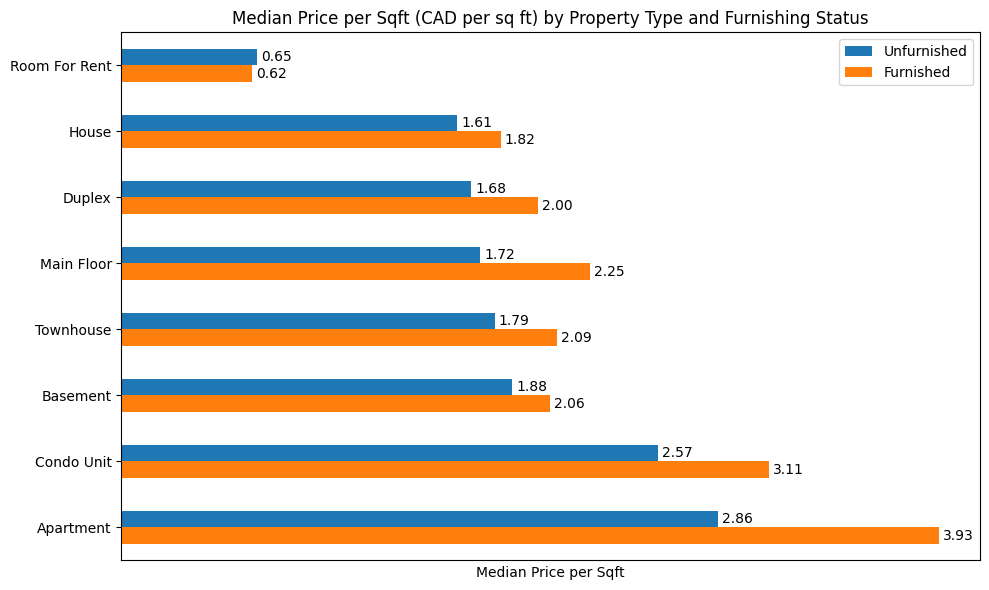

In [72]:
pivot_plot = pivot.rename(columns={False: "Unfurnished", True: "Furnished"})
pivot_sorted = pivot_plot.sort_values("Unfurnished", ascending=True)




ax = pivot_sorted[["Unfurnished", "Furnished"]].plot(
    kind="barh",
    figsize=(10,6)
)

plt.gca().invert_yaxis()


for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

ax.set_xticks([])
ax.set_xticklabels([])
ax.set_ylabel("")

plt.xlabel("Median Price per Sqft")
plt.title("Median Price per Sqft (CAD per sq ft) by Property Type and Furnishing Status")
plt.legend(title="")
plt.tight_layout()
plt.show()


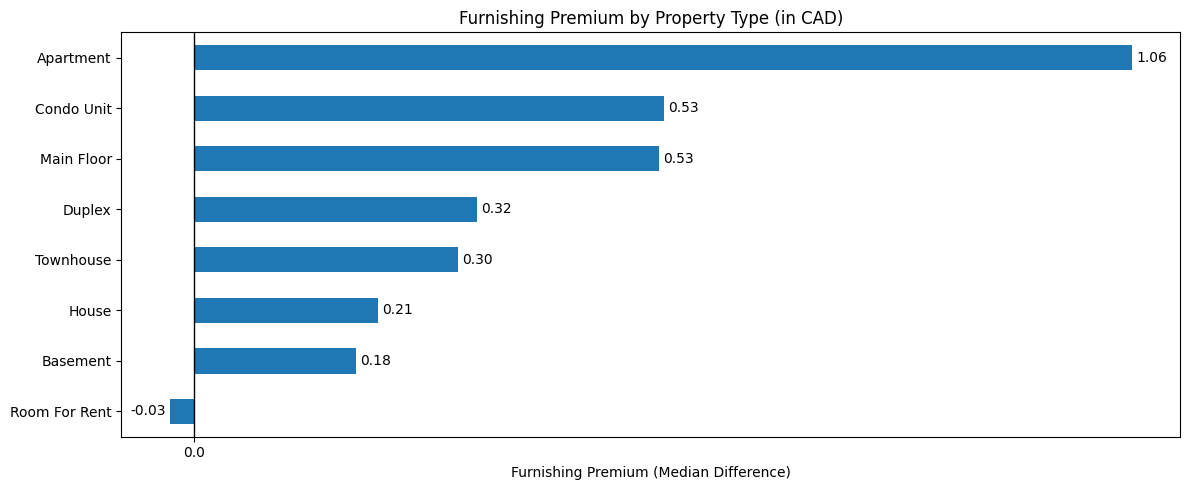

In [73]:
pivot_sorted = pivot.sort_values("premium", ascending=True)

ax = pivot_sorted["premium"].plot(
    kind="barh",
    figsize=(12,5)
)



plt.axvline(0, color="black", linewidth=1)


for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)


ax.set_xticks([0])
ax.set_xticklabels(["0.0"])
ax.set_ylabel("")

plt.xlabel("Furnishing Premium (Median Difference)")
plt.title("Furnishing Premium by Property Type (in CAD)")
plt.tight_layout()
plt.show()


In [75]:
q1_table = pivot_plot.copy()
q1_table["premium"] = q1_table["Furnished"] - q1_table["Unfurnished"]
q1_table = q1_table.loc[:, ["Unfurnished", "Furnished", "premium"]].round(2)
q1_table.sort_values("Unfurnished")


is_furnished,Unfurnished,Furnished,premium
type,,,
Room For Rent,0.65,0.62,-0.03
House,1.61,1.82,0.21
Duplex,1.68,2.0,0.32
Main Floor,1.72,2.25,0.53
Townhouse,1.79,2.09,0.3
Basement,1.88,2.06,0.18
Condo Unit,2.57,3.11,0.53
Apartment,2.86,3.93,1.06


How do the physical dimensions of a property (specifically square footage, number of bedrooms, and number of bathrooms)<br>
 correlate with rental prices? Among these variables, which one demonstrates the strongest linear relationship with the cost of rent?

In [76]:
df_analysis[["price", "sq_feet_num", "beds_num", "baths_num"]].corr()


,price,sq_feet_num,beds_num,baths_num
price,1.000000,0.494257,0.422982,0.494979
sq_feet_num,0.494257,1.000000,0.754830,0.711384
beds_num,0.422982,0.754830,1.000000,0.663303
baths_num,0.494979,0.711384,0.663303,1.000000


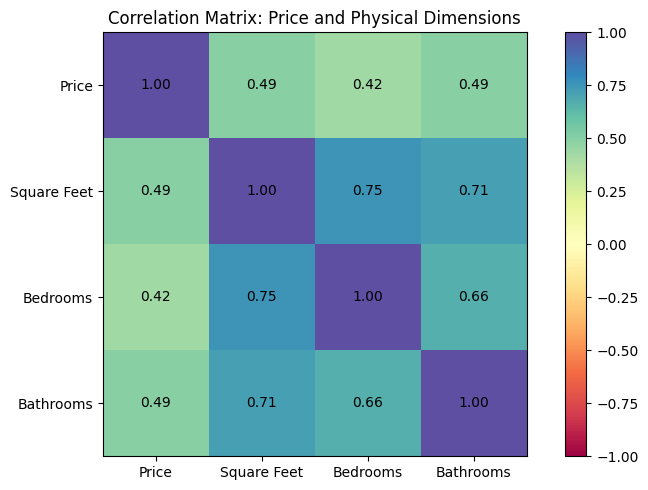

In [77]:
import matplotlib.pyplot as plt
import numpy as np

corr = df_analysis[["price", "sq_feet_num", "beds_num", "baths_num"]].corr()

labels = ["Price", "Square Feet", "Bedrooms", "Bathrooms"]

fig, ax = plt.subplots(figsize=(8,5))


cax = ax.imshow(corr, cmap="Spectral", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", color="black")

fig.colorbar(cax)

plt.title("Correlation Matrix: Price and Physical Dimensions")
plt.tight_layout()
plt.show()


What is the difference in median rental prices between pet-friendly properties and those that do not allow pets? <br> Additionally, how does this
"pet premium" differ across various provinces?

In [78]:
pet_median = (
    df_analysis
    .groupby("pet_friendly")["price"]
    .median()
)

pet_median


pet_friendly
False    2095.0
True     2100.0
Name: price, dtype: float64

In [79]:
pet_premium = pet_median[True] - pet_median[False]
pet_premium


np.float64(5.0)

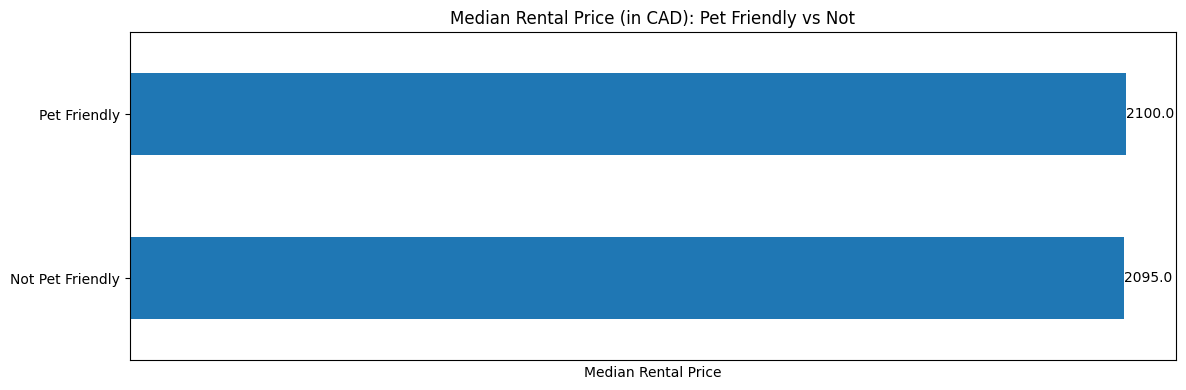

In [80]:
ax = pet_median.rename({False: "Not Pet Friendly", True: "Pet Friendly"}).plot(
    kind="barh",
    figsize=(12,4)
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")
ax.set_xticks([])
ax.set_ylabel("")

plt.xlabel("Median Rental Price")
plt.title("Median Rental Price (in CAD): Pet Friendly vs Not")
plt.tight_layout()
plt.show()


In [81]:
province_pivot = (
    df_analysis
    .groupby(["province", "pet_friendly"])["price"]
    .median()
    .unstack()
)

province_pivot["pet_premium"] = province_pivot[True] - province_pivot[False]

province_pivot.sort_values("pet_premium", ascending=False)


pet_friendly,False,True,pet_premium
province,,,
New Brunswick,1640.00,2032.5,392.50
Manitoba,1419.00,1708.0,289.00
Quebec,1800.00,2000.0,200.00
Newfoundland and Labrador,1020.00,1180.0,160.00
Ontario,2264.63,2400.0,135.37
Nova Scotia,2400.67,2425.0,24.33
Alberta,1985.00,1899.0,-86.00
British Columbia,2602.72,2318.0,-284.72
Saskatchewan,1799.50,1335.0,-464.50


In [82]:
pet_summary = (
    df_analysis
    .groupby(["province", "pet_friendly"])["price"]
    .agg(
        N="count",
        Median="median"
    )
    .reset_index()
)

pet_pivot = pet_summary.pivot(
    index="province",
    columns="pet_friendly"
)


pet_pivot.columns = [
    "N_NoPet", "N_Pet",
    "Median_NoPet", "Median_Pet"
]

pet_pivot["Premium"] = (
    pet_pivot["Median_Pet"] - pet_pivot["Median_NoPet"]
)

pet_pivot.sort_values("Premium", ascending=False)

,N_NoPet,N_Pet,Median_NoPet,Median_Pet,Premium
province,,,,,
New Brunswick,7,2,1640.00,2032.5,392.50
Manitoba,100,359,1419.00,1708.0,289.00
Quebec,299,1388,1800.00,2000.0,200.00
Newfoundland and Labrador,3,6,1020.00,1180.0,160.00
Ontario,945,4107,2264.63,2400.0,135.37
Nova Scotia,28,155,2400.67,2425.0,24.33
Alberta,2447,3808,1985.00,1899.0,-86.00
British Columbia,236,781,2602.72,2318.0,-284.72
Saskatchewan,34,473,1799.50,1335.0,-464.50


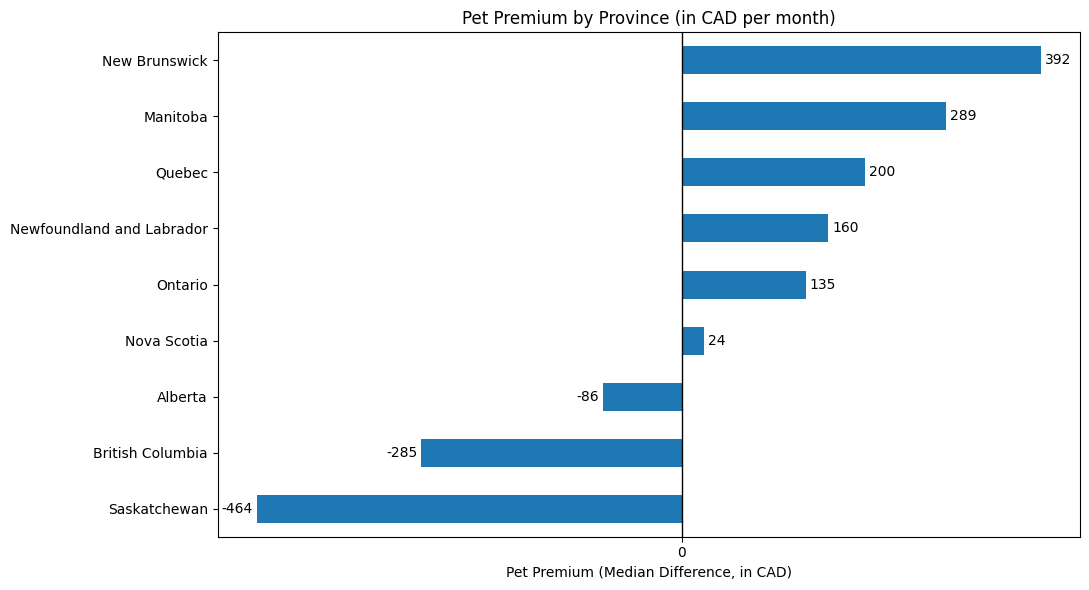

In [83]:
pivot_sorted = province_pivot.sort_values("pet_premium", ascending=True)

ax = pivot_sorted["pet_premium"].plot(
    kind="barh",
    figsize=(11,6)
)

plt.axvline(0, color="black", linewidth=1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

ax.set_xticks([0])
ax.set_xticklabels(["0"])

ax.set_ylabel("")
plt.xlabel("Pet Premium (Median Difference, in CAD)")
plt.title("Pet Premium by Province (in CAD per month)")
plt.tight_layout()
plt.show()


How is the distribution of rental prices across different provinces?

<Figure size 1200x600 with 0 Axes>

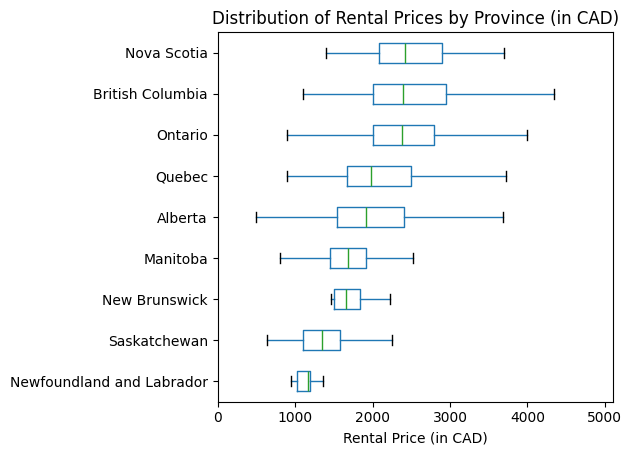

In [84]:
median_order = (
    df_analysis
    .groupby("province")["price"]
    .median()
    .sort_values()
    .index
)

df_sorted = df_analysis.copy()
df_sorted["province"] = pd.Categorical(
    df_sorted["province"],
    categories=median_order,
    ordered=True
)

plt.figure(figsize=(12,6))

df_sorted.boxplot(
    column="price",
    by="province",
    vert=False,
    grid=False,
    showfliers=False
)

plt.ylabel("")

plt.title("Distribution of Rental Prices by Province (in CAD)")
plt.suptitle("")
plt.xlabel("Rental Price (in CAD)")

x_cap = np.percentile(df_sorted["price"], 99)
plt.xlim(0, x_cap)

plt.tight_layout()
plt.show()


In [85]:
summary_table = (
    df_analysis
    .groupby("province")["price"]
    .describe(percentiles=[0.25, 0.5, 0.75])
)

summary_table = summary_table[["25%", "50%", "75%", "mean", "std"]]
summary_table.rename(columns={
    "25%": "Q1",
    "50%": "Median",
    "75%": "Q3",
    "mean": "Mean",
    "std": "Std"
}, inplace=True)

summary_table["IQR"] = summary_table["Q3"] - summary_table["Q1"]

summary_table.sort_values("Median")


,Q1,Median,Q3,Mean,Std,IQR
province,,,,,,
Newfoundland and Labrador,1020.0,1165.0,1195.0,1118.888889,140.995961,175.0
Saskatchewan,1102.5,1350.0,1575.0,1384.315582,405.292842,472.5
New Brunswick,1505.0,1655.0,1835.0,1706.111111,244.179465,330.0
Manitoba,1455.0,1688.0,1915.0,1729.840959,534.818856,460.0
Alberta,1545.0,1920.0,2400.0,2057.907926,891.507698,855.0
Quebec,1665.0,1975.0,2495.0,2151.618192,735.736734,830.0
Ontario,2000.0,2385.0,2800.0,2505.192781,773.665573,800.0
British Columbia,2000.0,2390.0,2950.0,2584.352724,941.611095,950.0
Nova Scotia,2085.0,2425.0,2895.0,2661.761038,1023.813797,810.0


In [86]:
summary_table = (
    df_analysis
    .groupby("province")["price"]
    .describe(percentiles=[0.25, 0.5, 0.75])
)

summary_table = summary_table[["count", "25%", "50%", "75%"]]

summary_table.rename(columns={
    "count": "N",
    "25%": "Q1",
    "50%": "Median",
    "75%": "Q3"
}, inplace=True)

summary_table["IQR"] = summary_table["Q3"] - summary_table["Q1"]

summary_clean = summary_table.sort_values("Median")

summary_clean

,N,Q1,Median,Q3,IQR
province,,,,,
Newfoundland and Labrador,9.0,1020.0,1165.0,1195.0,175.0
Saskatchewan,507.0,1102.5,1350.0,1575.0,472.5
New Brunswick,9.0,1505.0,1655.0,1835.0,330.0
Manitoba,459.0,1455.0,1688.0,1915.0,460.0
Alberta,6255.0,1545.0,1920.0,2400.0,855.0
Quebec,1687.0,1665.0,1975.0,2495.0,830.0
Ontario,5052.0,2000.0,2385.0,2800.0,800.0
British Columbia,1017.0,2000.0,2390.0,2950.0,950.0
Nova Scotia,183.0,2085.0,2425.0,2895.0,810.0


In [100]:
summary_clean = summary_table[["Q1", "Median", "Q3", "IQR"]]
summary_clean.sort_values("Median")


,Q1,Median,Q3,IQR
province,,,,
Newfoundland and Labrador,1020.0,1165.000,1195.00,175.00
Saskatchewan,1075.0,1347.000,1553.75,478.75
New Brunswick,1505.0,1655.000,1835.00,330.00
Manitoba,1505.0,1695.000,1950.00,445.00
Alberta,1619.0,2000.000,2490.00,871.00
Quebec,1675.0,2020.000,2495.25,820.25
British Columbia,1995.0,2360.000,2924.50,929.50
Ontario,2030.0,2416.695,2888.75,858.75
Nova Scotia,2100.0,2425.000,2875.00,775.00


How does the Furnishing Premium, which represents the additional
cost for a furnished unit, vary across different property types? <br> For
instance, is the price difference between unfurnished and furnished
units greater for a 'Basement' compared to an 'Apartment'?

In [87]:
furnishing_pivot = (
    df_analysis
    .groupby(["type", "is_furnished"])["price"]
    .median()
    .unstack()
)

furnishing_pivot["furnishing_premium"] = (
    furnishing_pivot[True] - furnishing_pivot[False]
)

furnishing_pivot["premium_pct"] = (
    furnishing_pivot["furnishing_premium"] /
    furnishing_pivot[False]
) * 100


furnishing_sorted = furnishing_pivot.sort_values("premium_pct")




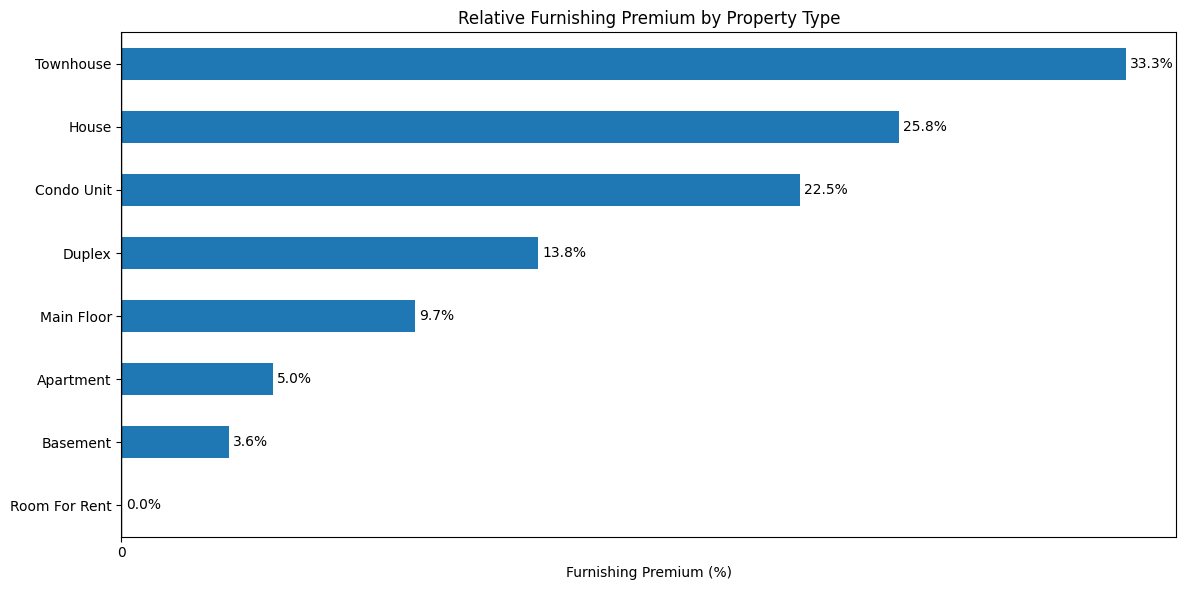

In [88]:

ax = furnishing_sorted["premium_pct"].plot(
    kind="barh",
    figsize=(12,6)
)

ax.axvline(0, color="black", linewidth=1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.set_xlabel("Furnishing Premium (%)")
ax.set_ylabel("")
ax.set_xticks([0])
ax.set_xticklabels(["0"])

plt.title("Relative Furnishing Premium by Property Type")
plt.tight_layout()
plt.show()



In [89]:
summary_q5 = furnishing_sorted[
    [False, True, "furnishing_premium", "premium_pct"]
].rename(columns={
    False: "Unfurnished Median",
    True: "Furnished Median",
    "furnishing_premium": "Premium (CAD)",
    "premium_pct": "Premium (%)"
})

summary_q5


is_furnished,Unfurnished Median,Furnished Median,Premium (CAD),Premium (%)
type,,,,
Room For Rent,850.0,850.0,0.0,0.000000
Basement,1545.0,1600.0,55.0,3.559871
Apartment,2095.0,2200.0,105.0,5.011933
Main Floor,2187.0,2400.0,213.0,9.739369
Duplex,2350.0,2675.0,325.0,13.829787
Condo Unit,2000.0,2450.0,450.0,22.500000
House,2800.0,3522.5,722.5,25.803571
Townhouse,2250.0,3000.0,750.0,33.333333


In [104]:
furn_summary = (
    df_analysis
    .groupby(["type", "is_furnished"])["price"]
    .agg(
        N="count",
        Median="median"
    )
    .reset_index()
)

furn_pivot = furn_summary.pivot(
    index="type",
    columns="is_furnished"
)


furn_pivot.columns = [
    "N_Unfurnished", "N_Furnished",
    "Median_Unfurnished", "Median_Furnished"
]

furn_pivot["Premium"] = (
    furn_pivot["Median_Furnished"] - furn_pivot["Median_Unfurnished"]
)

furn_pivot["Premium_pct"] = (
    furn_pivot["Premium"] / furn_pivot["Median_Unfurnished"] * 100
)

furn_pivot.sort_values("Premium", ascending=False)

,N_Unfurnished,N_Furnished,Median_Unfurnished,Median_Furnished,Premium,Premium_pct
type,,,,,,
Townhouse,1255,81,2350.0,3195.0,845.0,35.957447
House,1061,137,2900.0,3500.0,600.0,20.689655
Condo Unit,1373,422,2025.0,2495.0,470.0,23.209877
Duplex,343,39,2400.0,2675.0,275.0,11.458333
Main Floor,588,50,2200.0,2400.0,200.0,9.090909
Apartment,13170,408,2095.0,2280.0,185.0,8.830549
Basement,1001,169,1550.0,1600.0,50.0,3.225806
Room For Rent,55,254,850.0,850.0,0.0,0.000000


In [6]:
df.duplicated().sum()

np.int64(6726)

In [7]:
df[df.duplicated()].head()

,rentfaster_id,city,province,address,latitude,longitude,lease_term,type,price,beds,baths,sq_feet,link,furnishing,availability_date,smoking,cats,dogs
4,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2495.0,2 Beds,2.5,1403,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True
5,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2095.0,2 Beds,2.5,1403,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,November 18,Non-Smoking,True,True
79,453882,Airdrie,Alberta,45 Gateway Drive,51.304497,-114.011563,Long Term,Apartment,1630.0,1 Bed,1,616,/ab/airdrie/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,Immediate,Non-Smoking,True,True
81,453882,Airdrie,Alberta,45 Gateway Drive,51.304497,-114.011563,Long Term,Apartment,1630.0,1 Bed,1,616,/ab/airdrie/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,July 01,Non-Smoking,True,True
82,453882,Airdrie,Alberta,45 Gateway Drive,51.304497,-114.011563,Long Term,Apartment,1630.0,1 Bed,1,616,/ab/airdrie/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,July 01,Non-Smoking,True,True


In [8]:
df.duplicated(subset="rentfaster_id").sum()

np.int64(16157)

In [10]:
df["rentfaster_id"].nunique()


9614

In [11]:

len(df)

25771